# 한국어 챗봇(질문-답변) 만들기

## 개요

- 학습 내용 이해  
  - 트랜스포머와 인코더 디코더: 트랜스포머에서 사용되는 인코더와 디코더를 알아보고, 전체적인 구조를 파악합니다.
  - 트랜스포머의 입력 이해하기: 트랜스포머의 입력 방식을 알아보고, PositionalEncoding Layer의 코드를 학습합니다.
  - 어텐션? 어텐션!: 어텐션 메커니즘에 대해서 알아보고, 트랜스포머에서 사용되는 3가지 어텐션을 파악합니다.
  - 스케일드 닷 프로덕트 어텐션: 스케일드 닷 프로덕트 어텐션을 알아보고, 함수 코드로 구현하며 학습합니다.
  - 머리가 여러 개인 어텐션: 멀티 헤드 어텐션을 알아보고, 코드로 구현하며 학습합니다.
  - 마스킹: 트랜스포머에서 사용하는 2가지 마스킹(Padding Masking, Look ahead Masking)에 대해서 알아보고, 코드를 통해 어떻게 사용되는지 학습합니다.
  - 인코더: 인코더를 설계하고, 코드로 구현해보며 학습합니다.
  - 디코더: 디코더를 설계하고, 코드로 구현해보며 학습합니다.
  - 챗봇의 병렬 데이터 받아오기: 학습에 사용할 데이터셋을 준비하는 과정을 수행합니다.
  - 병렬 데이터 전처리하기: 준비된 데이터를 학습시키기 위해 전처리과정을 수행하며, 교사 강요에 대해서 학습니다.
  - 모델 정의 및 학습하기: 트랜스포머 모델을 정의하고 훈련까지 수행합니다.
  - 챗봇 테스트하기: 학습된 트랜스포머를 사용하여 테스트를 진행합니다.
   
- 학습 목표
  - 트랜스포머의 인코더 디코더 구조 이해할 수 있습니다.
  - 내부 단어 토크나이저 사용할 수 있습니다.
  - 셀프 어텐션 이해할 수 있습니다.
  - 한국어에도 적용할 수 있습니다.

- [트랜스포머 구조](https://arxiv.org/pdf/1706.03762)  
   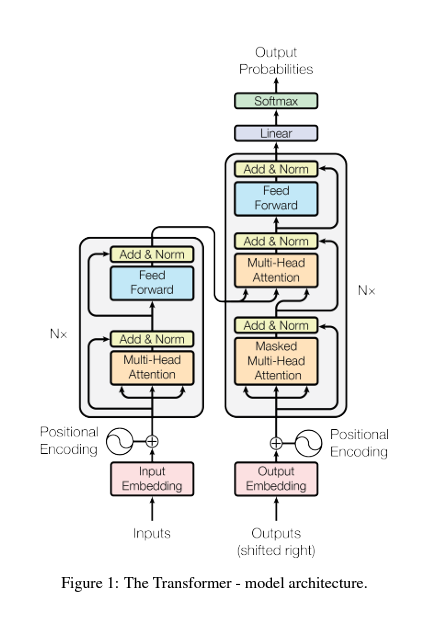  

- 인코더와 디코더  
   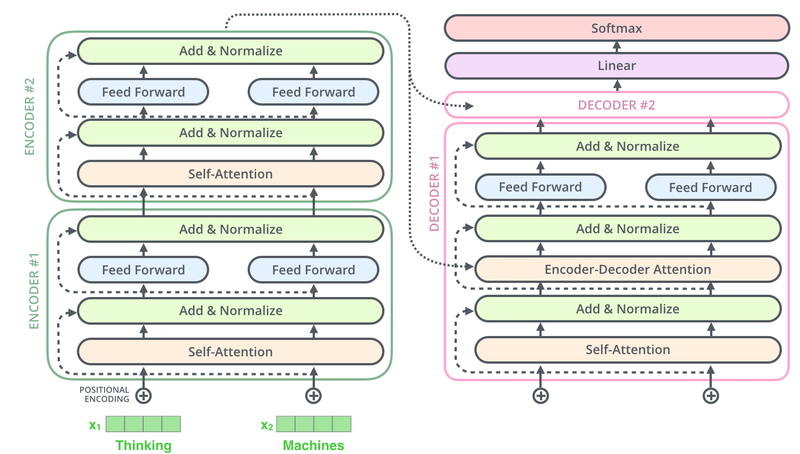  

- 포지셔널 인코딩  
   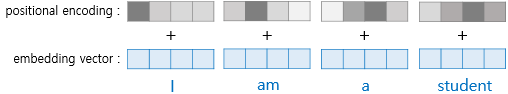  
   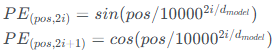  
   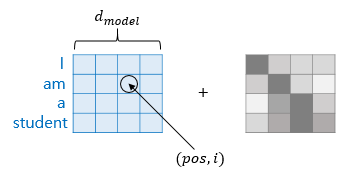  
   - $d_{model}$ : 임베딩 벡터의 차원
   - $pos$ : 입력 문장에서 임베딩 벡터의 위치
   - $i$ : 임베딩 벡터 내의 차원의 인덱스 

## 준비

In [3]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.3 MB/s eta 0:00:00


In [221]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1. 데이터 수집하기

In [16]:
!mkdir -p ~/work/transformer_chatbot/data/ && cd ~/work/transformer_chatbot/data/ #폴더생성
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv #파일 다운로드
!mv ChatbotData.csv ~/work/transformer_chatbot/data #파일 옮기기

--2026-02-05 06:04:57--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-02-05 06:04:58--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.1’

ChatbotData.csv.1   100%[===================>] 868.99K  4.94MB/s    in 0.2s    

2026-02-05 06:04:58 (4.94 MB/s) - ‘ChatbotData.csv.1’ saved [889842/889842]



In [248]:
path_to_dataset = os.path.expanduser("~/work/transformer_chatbot/data") #데이터 폴더 절대경로
path_to_csv = os.path.join(path_to_dataset, 'ChatbotData.csv') #개별 파일 경로 설정

print("path_to_dataset:", path_to_dataset)
print("path_to_lines:", path_to_csv)

path_to_dataset: /home/jovyan/work/transformer_chatbot/data
path_to_lines: /home/jovyan/work/transformer_chatbot/data/ChatbotData.csv


In [249]:
df = pd.read_csv(path_to_csv) #데이터 미리보기
df.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## Step 2. 데이터 전처리하기

### 전처리(1)
  - 전체 데이터셋의 질문과 답변의 쌍을 추출한다.
  - 양끝 공백 제거, 단어와 구두점 사이에 공백 추가, 여러개 공백은 1개로 축소
  - 한글, 알파벳, 숫자, ! ? , . 이 4개의 구두점을 제외하고 다른 특수문자는 모두 제거

In [250]:
# 전처리 함수
def preprocess_sentence(sentence):
    # 양끝 공백 제거
    sentence = sentence.strip()
    # 구두점 앞에 공백 삽입 (예: "가네요." -> "가네요 .")
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 여러 개의 공백은 하나로 축소
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 한글, 영어, 숫자, 구두점 외의 불필요한 특수문자 제거
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

In [251]:
def read_data(path_to_csv, max_samples=50000):
    # CSV 파일을 읽어옵니다 (구분자가 콤마인 경우)
    # 데이터 구조: Q, A, label
    df = pd.read_csv(path_to_csv)
    
    pairs = []
    
    # max_samples와 실제 데이터 개수 중 작은 것을 선택하여 루프
    num_rows = min(max_samples, len(df))
    
    for i in range(num_rows):
        # Q와 A 컬럼의 데이터를 가져와 전처리 후 튜플로 묶기
        q_text = preprocess_sentence(str(df.iloc[i]['Q']))
        a_text = preprocess_sentence(str(df.iloc[i]['A']))
        
        pairs.append((q_text, a_text))
        
    return pairs

In [253]:
pairs = read_data(path_to_csv)
print(pairs[0])  # 데이터 확인
print('전체 샘플 수 :', len(pairs))

('12시 땡 !', '하루가 또 가네요 .')
전체 샘플 수 : 11823


## Step 3. 전처리(2) - SentencePiece 사용하여 병렬 데이터 전처리하기
  - Google SentencePiece 를 토크나이저로 사용한다.
  - 단어보다 더 작은 단위인 Subword를 기준으로 토크나이징하고, 각 토큰을 고유한 정수로 인코딩 한다.
  - 각 문장을 토큰화하고 각 문장의 시작과 끝을 나타내는 START_TOKEN 및 END_TOKEN을 추가한다.
  - 최대 길이 MAX_LENGTH가 넘는 문장들은 필터링한다.
  - MAX_LENGTH보다 길이가 짧은 문장들은 MAX_LENGTH에 맞도록 패딩 한다.

In [254]:
# 토크나이저 학습하기
## 질문-답변 SentencePiece 모델을 훈련, 토크나이저가 담길 model / vocab 파일을 생성
corpus_file = "clean_corpus.txt" # 임시로 빈파일 생성

with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs: # 전처리(1) 후 pairs된 Q, A 결과가 들어감
        f.write(q + "\n")
        f.write(a + "\n")

In [369]:
# vocab_size 기준 설정하기
from collections import Counter

# 1. 모든 문장을 단어 단위로 쪼개어 빈도 측정
all_sentences = []
for q, a in pairs:
    all_sentences.append(q)
    all_sentences.append(a)

word_counts = Counter()
for sentence in all_sentences:
    word_counts.update(sentence.split())

# 2. 임계값(threshold) 설정
threshold = 2
total_cnt = len(word_counts)
rare_cnt = sum(1 for count in word_counts.values() if count < threshold)

# 3. 결과 출력
print('전체 단어(어절) 개수 :', total_cnt)
print(f'등장 빈도가 {threshold}번 미만인 희귀 단어 수: {rare_cnt}')
print(f'빈도 {threshold}번 이상인 단어 수: {total_cnt - rare_cnt}')

전체 단어(어절) 개수 : 20651
등장 빈도가 2번 미만인 희귀 단어 수: 11172
빈도 2번 이상인 단어 수: 9479


In [306]:
VOCAB_SIZE=8000
spm.SentencePieceTrainer.Train(
    input=corpus_file, # input 파일로 train 모델 생성함. 
    model_prefix="spm_chatbot",
    vocab_size=VOCAB_SIZE,
    character_coverage=1.0,
    model_type="bpe", # BPE 알고리즘 사용
    max_sentence_length=999999, # 모든 문장을 받음
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: clean_corpus.txt
  input_format: 
  model_prefix: spm_chatbot
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differ

In [259]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

=2040 all=34397 active=1763 piece=▁연락하지
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=14 size=2060 all=34440 active=1806 piece=간이
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=14 size=2080 all=34574 active=1940 piece=▁내는
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=14 size=2100 all=34614 active=1980 piece=▁조급
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=14 min_freq=7
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=14 size=2120 all=34645 active=1757 piece=▁상황이
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=14 size=2140 all=34637 active=1749 piece=▁썸남한테
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=14 size=2160 all=34623 active=1735 piece=▁잊어버리세요
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=13 size=2180 all=34713 active=1825 piece=어진
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=13 size=2200 all=34836 active=1948 piece=▁남의
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=13 min_freq=7
bpe_model_trainer.cc(268) LOG(INFO) Added: 

True

In [260]:
# 예제 문장
sentence = "안녕하세요!!"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)


전처리 후의 문장: 안녕하세요 ! !
Tokenized: ['▁안녕하세요', '▁!', '▁!']
Encoded: [4617, 108, 108]
Decoded: 안녕하세요 ! !


질문 최대 길이: 23
답변 최대 길이: 31
질문 평균 길이: 7.40
답변 평균 길이: 7.78


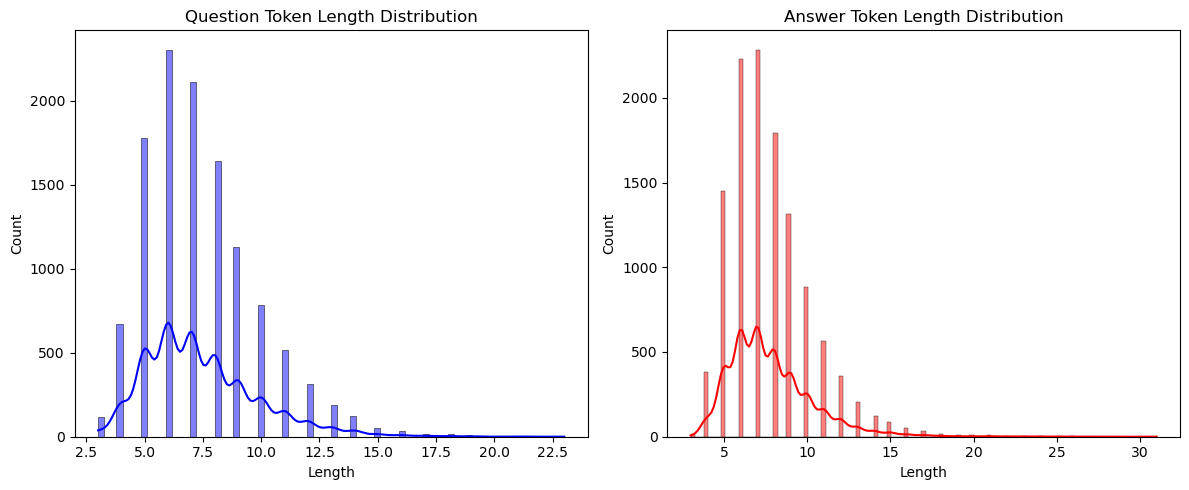

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns

def show_token_dist(pairs, sp):
    # 각 문장별 토큰 개수 리스트 생성 (START, END 토큰 포함 기준)
    q_len = [len(sp.encode(q)) + 2 for q, a in pairs]
    a_len = [len(sp.encode(a)) + 2 for q, a in pairs]

    print(f"질문 최대 길이: {max(q_len)}")
    print(f"답변 최대 길이: {max(a_len)}")
    print(f"질문 평균 길이: {sum(q_len)/len(q_len):.2f}")
    print(f"답변 평균 길이: {sum(a_len)/len(a_len):.2f}")

    # 시각화
    plt.figure(figsize=(12, 5))

    # 질문 토큰 개수 분포
    plt.subplot(1, 2, 1)
    sns.histplot(q_len, color='blue', kde=True)
    plt.title('Question Token Length Distribution')
    plt.xlabel('Length')
    plt.ylabel('Count')

    # 답변 토큰 개수 분포
    plt.subplot(1, 2, 2)
    sns.histplot(a_len, color='red', kde=True)
    plt.title('Answer Token Length Distribution')
    plt.xlabel('Length')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

# 함수 실행
show_token_dist(pairs, sp)

In [262]:
MAX_LENGTH = 40

## Step 4. Transformer model 구성하기

### Positional encoding

In [263]:
#포지셔널 행렬 구현하기
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

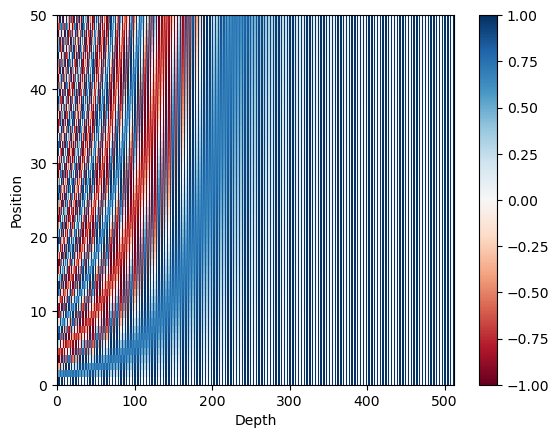

In [264]:
sample_pos_encoding = PositionalEncoding(50, 512) # (행, 열) = (최대 문장의 길이, 임베딩 차원)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

### Attention  

In [265]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [266]:
#멀티헤드 어텐션 (스케일드 닷 프로덕트 어텐션 포함됨)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [267]:
# 1. 패딩 마스킹
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [268]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


In [269]:
# 2. 룩 어헤드 마스킹 (패딩 마스크 포함됨)
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [270]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape) #대각선 형태로 숫자 1이 채워

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [271]:
x2 = torch.tensor([[0, 5, 1, 5, 5]]) # 0인 단어가 있다면? 패딩하고 호출함
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


### 인코더 층 만들기  
  - self-attention -> FFNN(feed forward neural network)

In [272]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


In [273]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

### 디코더 층 만들기

In [274]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

디코더 층을 쌓아 올리기

In [275]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

### 트랜스포머 함수 정의

In [276]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

### 데이터셋 구현하기  
- 트랜스포머 디코더에 교사 강요(Teacher Forcing) 언어 모델의 훈련 기법 활용하기
  - 이전 단계의 예측값 대신 정답을 다음 단계의 입력으로 넣어주는 기법
  - 훈련모드에서는 교사강요, 추론모드에서는 이전단계의 예측값이 다음 단계의 입력으로 들어감
  - 장점? 빠른 학습과 학습 안정성
  - 단점? 노출 편향. 너무 정답에게만 의존하게 됨

In [277]:
class ChatbotDataset(Dataset):
    def __init__(self, pairs, sp, max_length=MAX_LENGTH):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        # SentencePiece 메서드는 소문자(encode_as_ids)가 표준입니다.
        # bos, eos, pad ID 미리 가져오기
        bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1
        eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2
        pad_id = sp.pad_id() if sp.pad_id() >= 0 else 0

        for q_text, a_text in pairs:
            # 1) 토크나이즈 (메서드명 소문자로 수정)
            q_ids = sp.encode_as_ids(q_text)
            a_ids = sp.encode_as_ids(a_text)

            # 2) 토큰 조립 (한국어 문맥을 위해 BOS/EOS 추가)
            # 질문(Encoder input): [BOS] + 질문 + [EOS]
            q_tokens = [bos_id] + q_ids + [eos_id]
            # 답변(Full Answer): [BOS] + 답변 + [EOS]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한 (최대 길이보다 길면 자르기 - 버리는 것보다 효율적)
            if len(q_tokens) > max_length:
                q_tokens = q_tokens[:max_length]
            if len(a_tokens) > max_length:
                a_tokens = a_tokens[:max_length]

            # 4) 고정 길이 패딩 (모든 텐서 길이를 max_length로 통일)
            q_pad = q_tokens + [pad_id] * (max_length - len(q_tokens))
            a_pad = a_tokens + [pad_id] * (max_length - len(a_tokens))

            # 5) Teacher Forcing용 데이터 분리
            # Transformer는 입력을 넣어 다음 단어를 맞추는 구조이므로
            # dec_input: [BOS, 단어1, 단어2, PAD]  (마지막 토큰 제외)
            # target:    [단어1, 단어2, EOS, PAD]  (첫 번째 BOS 제외)
            dec_input = a_pad[:-1]
            target = a_pad[1:]

            # 중요: 슬라이싱으로 인해 길이가 max_length - 1이 되었으므로, 
            # 모델의 기대 차원에 맞게 다시 하나를 패딩하거나 길이를 맞춰줍니다.
            dec_input += [pad_id] 
            target += [pad_id]

            self.data.append({
                "enc_input": q_pad,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (torch.tensor(sample["enc_input"], dtype=torch.long),
                torch.tensor(sample["dec_input"], dtype=torch.long),
                torch.tensor(sample["target"], dtype=torch.long))

In [278]:
dataset = ChatbotDataset(pairs, sp, max_length=MAX_LENGTH)

In [279]:
for encoder_input, decoder_input, decoder_label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

텐서 크기 : torch.Size([40])
tensor([   1, 5553, 6812, 3202,  108,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
12시 땡 !
tensor([   1, 4486,  214, 5923,    4,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
하루가 또 가네요 .
tensor([4486,  214, 5923,    4,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
하루가 또 가네요 .


### Dataloader 구성하기

In [343]:
dataloader = DataLoader(dataset,batch_size=64,shuffle=True)

In [344]:
for encoder_input, decoder_input, decoder_label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

torch.Size([64, 40])
torch.Size([64, 40])
torch.Size([64, 40])


In [345]:
# 첫 번째 배치의 첫 번째 문장만 확인
enc_sample = encoder_input[0].tolist()
dec_sample = decoder_input[0].tolist()
label_sample = decoder_label[0].tolist()

print("인코더 입력 (질문):", sp.decode_ids(enc_sample))
print("-" * 30)
print("디코더 입력 (Teacher Forcing):", sp.decode_ids(dec_sample), dec_sample[:10]) #1개씩 미뤄져있음
print("디코더 타겟 (정답):", sp.decode_ids(label_sample), label_sample[:10])

인코더 입력 (질문): 연애는 하기 싫은데 썸은 타고 싶어 .
------------------------------
디코더 입력 (Teacher Forcing): 시작하기 전 두근거림을 더 좋아하나 봐요 . 아니면 연애에 대한 두려움을 가지고 있을 수도 있을 듯 합니다 . [1, 5260, 103, 6637, 64, 3516, 1073, 4, 2433, 3100]
디코더 타겟 (정답): 시작하기 전 두근거림을 더 좋아하나 봐요 . 아니면 연애에 대한 두려움을 가지고 있을 수도 있을 듯 합니다 . [5260, 103, 6637, 64, 3516, 1073, 4, 2433, 3100, 829]


### 모델 생성

In [346]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

In [347]:
# 손실 함수(Loss function)
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [348]:
# 커스텀 된 학습률(Learning rate)
'''
트랜스포머 모델은 처음에 무작위로 설정된 가중치 때문에 학습 초기에 매우 불안정합니다.
초반의 안정성과 후반의 정밀도를 모두 잡기 위한 필수적인 장치입니다.
'''
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

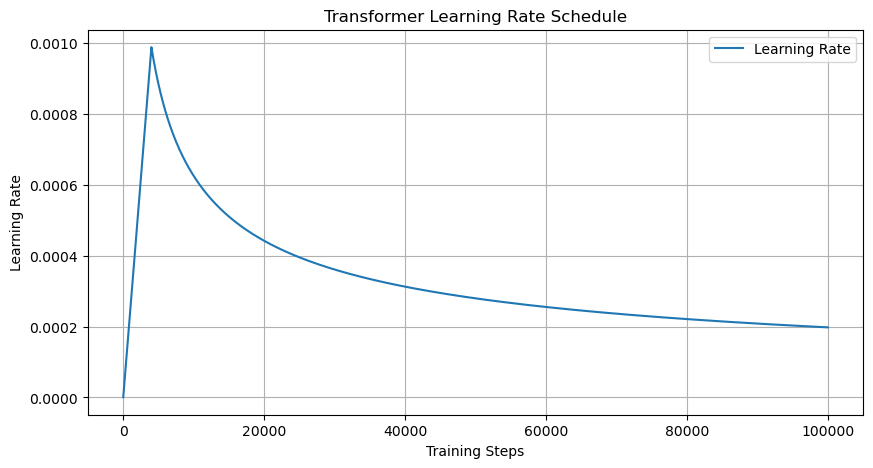

In [349]:
# 하이퍼파라미터 설정
d_model = D_MODEL
warmup_steps = 4000 #peak가 0.001 이 이상적. loss가 거의 안변하면 학습률이 낮으니 줄이는 것을 추천함
total_steps = 100000  # 총 학습 스텝. 1epoch steps=total/batch size

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


### 모델 컴파일

In [350]:
# Optimizer 정의
# 초기 학습률 설정
initial_lr = 1.0 # 핵심***
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9, lr=initial_lr)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=warmup_steps))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask # 모델이 예측한 값과 실제 정답이 같은지 확인 & 그 자리가 패딩(0)이 아닐 때만 정답으로 인정
    acc = correct.float().sum() / mask.float().sum() # 실제 단어가 들어있던 개수 중에서 몇 개를 맞췄는지를 계산함
    return acc

In [351]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 훈련하기

In [352]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

In [353]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

In [354]:
'''
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=30,  # 원하는 에폭 수
    device=device
)
'''

'\n%%time\n\ntrain(\n    model=model,\n    dataloader=dataloader,\n    optimizer=optimizer,\n    loss_function=loss_function,\n    scheduler=scheduler,\n    num_epochs=30,  # 원하는 에폭 수\n    device=device\n)\n'

In [355]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    
    # 히스토리 저장을 위한 리스트 초기화
    history = {
        'loss': [],
        'acc': []
    }

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        model.train() # 학습 모드 명시
        
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        
        # 에폭별 결과 저장
        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
    
    return history # 학습 기록 반환

In [356]:
%%time

# 함수 실행 시 결과값을 history 변수에 담습니다.
history = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=30,
    device=device
)

[Epoch 1, Step 0] Loss: 9.1589, Acc: 0.0000
[Epoch 1, Step 100] Loss: 7.3379, Acc: 0.3140
Epoch 1 Completed - Avg Loss: 7.8734, Avg Acc: 0.1847
[Epoch 2, Step 0] Loss: 6.5699, Acc: 0.2963
[Epoch 2, Step 100] Loss: 6.2282, Acc: 0.2818
Epoch 2 Completed - Avg Loss: 6.1852, Avg Acc: 0.2886
[Epoch 3, Step 0] Loss: 5.4965, Acc: 0.3171
[Epoch 3, Step 100] Loss: 5.6515, Acc: 0.2968
Epoch 3 Completed - Avg Loss: 5.7025, Avg Acc: 0.2965
[Epoch 4, Step 0] Loss: 5.5539, Acc: 0.2998
[Epoch 4, Step 100] Loss: 5.7327, Acc: 0.2890
Epoch 4 Completed - Avg Loss: 5.4020, Avg Acc: 0.3095
[Epoch 5, Step 0] Loss: 4.8410, Acc: 0.3466
[Epoch 5, Step 100] Loss: 5.2191, Acc: 0.3212
Epoch 5 Completed - Avg Loss: 5.0883, Avg Acc: 0.3224
[Epoch 6, Step 0] Loss: 4.6895, Acc: 0.3521
[Epoch 6, Step 100] Loss: 4.6549, Acc: 0.3698
Epoch 6 Completed - Avg Loss: 4.7691, Avg Acc: 0.3380
[Epoch 7, Step 0] Loss: 4.6200, Acc: 0.3289
[Epoch 7, Step 100] Loss: 4.3905, Acc: 0.3614
Epoch 7 Completed - Avg Loss: 4.4498, Avg Acc:

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

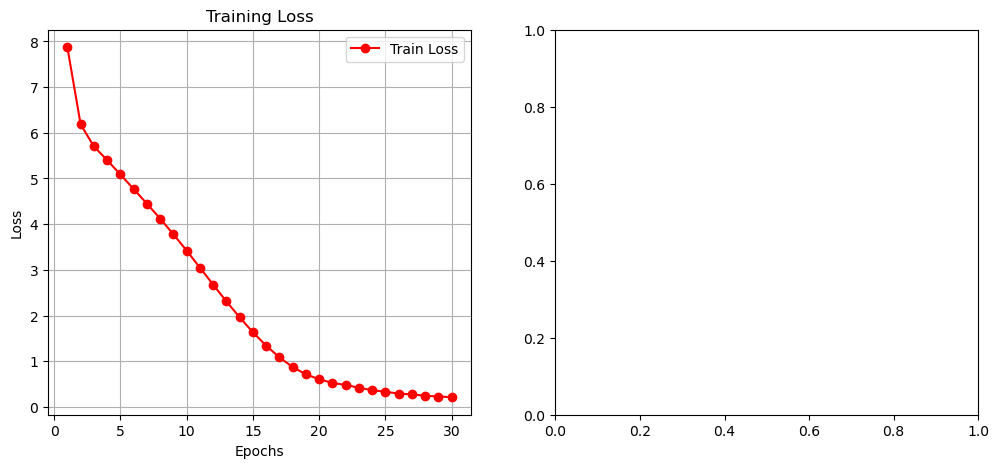

In [366]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'r-o', label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['acc'], 'b-o', label='Train Acc')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png') # 이미지 파일로 저장
    plt.show()

# 그래프 출력
plot_history(history)

## Step 5. 챗봇 테스트하기

In [359]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40
    
    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [360]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [361]:
sentence = '너는 누구니?'
sentence_generation(model, sentence, sp, device)

입력 : 너는 누구니?
출력 : 저는 위로해드리는 로봇이에요 .


'저는 위로해드리는 로봇이에요 .'

In [362]:
sentence = "나 고민이 있어"
sentence_generation(model, sentence, sp, device)

입력 : 나 고민이 있어
출력 : 네 말씀하세요 .


'네 말씀하세요 .'

In [373]:
sentence = "너는 고민이 뭐야?"
sentence_generation(model, sentence, sp, device)

입력 : 너는 고민이 뭐야?
출력 : 저는 고민이 없어요 .


'저는 고민이 없어요 .'

**회고**
- 30epochs 까지 학습 정확도가 30%대로 머물러서 코드상 문제가 있다고 생각하고 한참 헤메었으나 initial_lr을 적용하고난 후 제대로 학습이 되었다.
- initial_lr = 1.0
- optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9, lr=initial_lr)
